In [1]:
%pip install --upgrade nilearn -q --progress-bar off

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import nilearn.signal
%config InlineBackend.figure_format = 'retina'

from rich import pretty
pretty.install()

# `nilearn.signal.clean` — the five knobs

`nilearn.signal.clean(signals, ...)` is the workhorse fMRI preprocessing call. It bundles five operations behind one function, and they split into **two categories**:

| Category          | Knob                     | What it does                    |
| ----------------- | ------------------------ | ------------------------------- |
| Signal processing | `detrend`                | remove slow drift               |
| Signal processing | `standardize`            | rescale to mean 0, std 1        |
| Signal processing | `high_pass` / `low_pass` | temporal frequency filters      |
| **Data hygiene**  | `ensure_finite`          | replace `NaN` / `±Inf` with `0` |

The way to build intuition: construct a synthetic signal out of **known** parts, plant one bad value, then turn a single knob at a time and watch what each one removes.

This notebook grew out of [facebookresearch/neuroai#130](https://github.com/facebookresearch/neuroai/issues/130) — a wrapper that skipped `clean()` entirely when the signal-processing knobs were off, silently disabling `ensure_finite` along with them. The cells below are _why that matters_.


In [3]:
# nilearn.signal.clean expects shape (time, n_features). One feature (one voxel).
t_r = 2.0                      # repetition time: 2 s per sample (a typical fMRI TR)
n   = 200
t   = np.arange(n) * t_r       # time axis in seconds

baseline   = 100.0                          # BOLD has a big DC offset
drift      = 0.05 * t                       # slow linear drift (scanner warm-up etc.)
slow_signal= 3.0 * np.sin(2*np.pi*0.02 * t) # the "neural" signal we want to KEEP (0.02 Hz)
fast_noise = 1.0 * np.sin(2*np.pi*0.20 * t) # high-frequency nuisance (0.20 Hz)

In [4]:
clean_truth = baseline + drift + slow_signal + fast_noise
signal = clean_truth.copy().reshape(-1, 1)  # (time, 1)
signal[50, 0] = np.nan                       # drop in one non-finite value

## The signal and the planted `NaN`

Our synthetic voxel is `baseline (100) + linear drift + slow 0.02 Hz wave + fast 0.20 Hz noise`. The slow wave is the "neural" signal we want to keep; drift and fast noise are the nuisances.

We then set one sample to `NaN`. That isn't artificial paranoia — non-finite values are **normal** in fMRI: brain masks, registration/resampling, and surface projection all leave `NaN` where there is no valid data. Downstream models choke on a single `NaN`, so scrubbing it is routine hygiene, not an edge case.


raw input                    mean=109.975  std= 5.999  finite=False


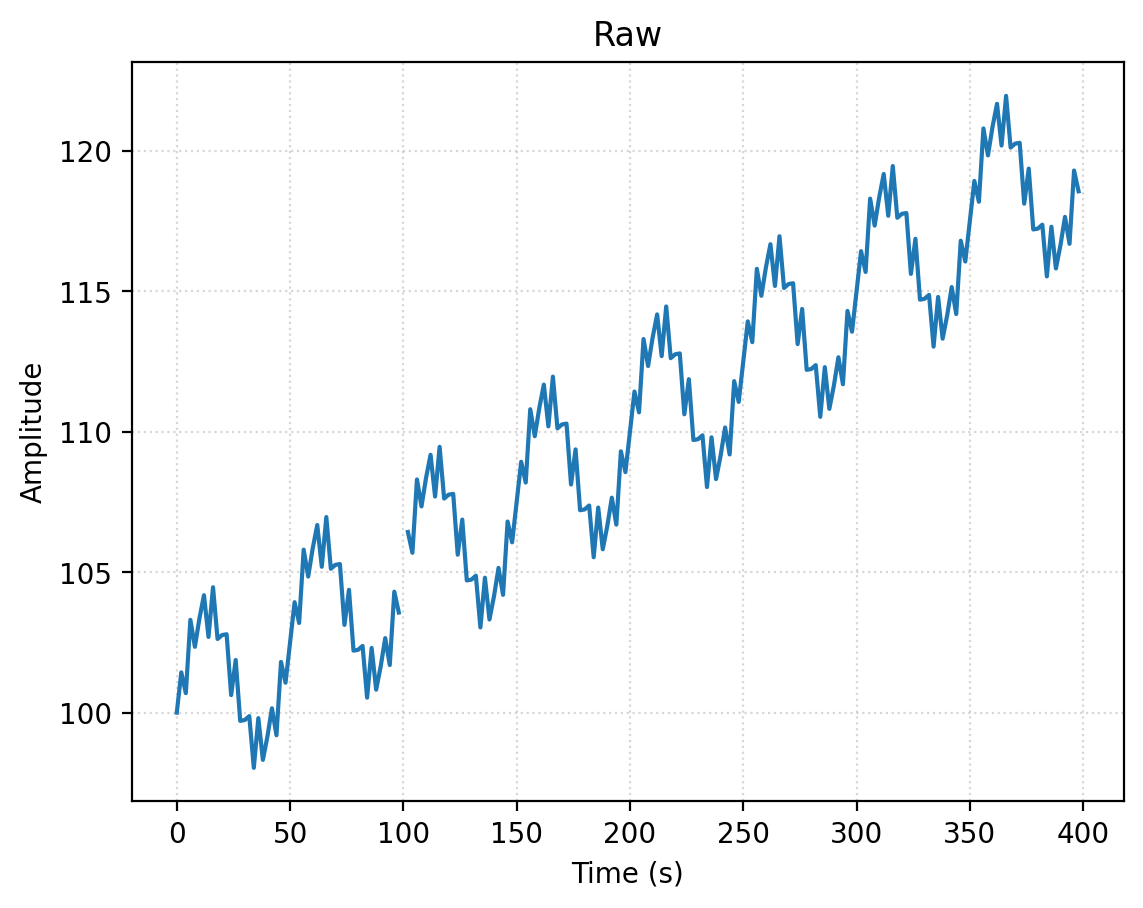

In [5]:
def describe(name, x):
    x = np.asarray(x).ravel()
    print(f"{name:<28} mean={np.nanmean(x):7.3f}  std={np.nanstd(x):6.3f}  "
          f"finite={np.isfinite(x).all()}")

describe("raw input", signal)

plt.title("Raw")
plt.plot(t, signal)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

## Knob 1 — `ensure_finite`: data hygiene

The odd one out: it's about data _validity_, not signal _shape_. It replaces `NaN` / `+Inf` / `-Inf` with `0` and touches nothing else — watch sample 50 go from `NaN` → `0`.

**Note:** in `nilearn`, `ensure_finite` **defaults to `False`** — you have to ask for it explicitly.


ensure_finite only           mean=109.425  std= 9.797  finite=True
  -> sample 50 was NaN, now: 0.0


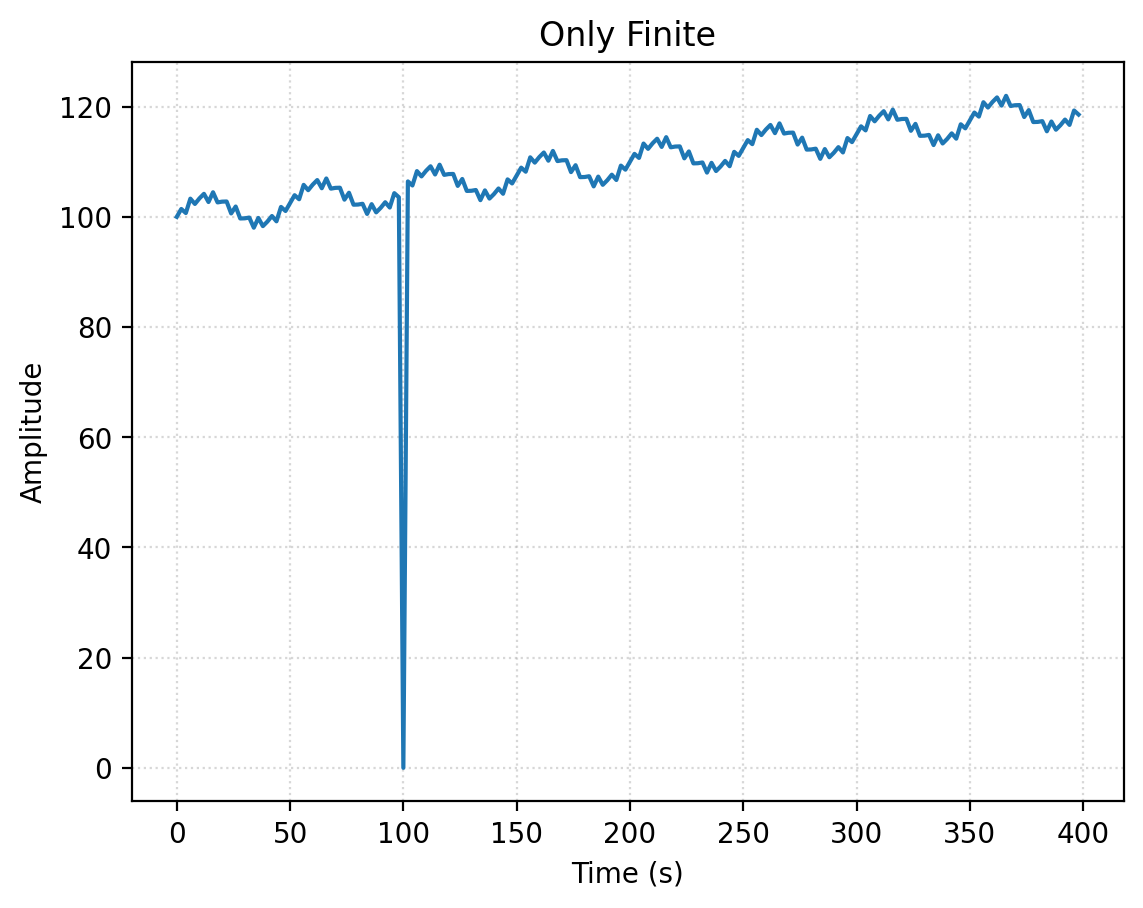

In [6]:
only_finite = nilearn.signal.clean(
    signal,
    detrend=False,
    standardize=False,
    ensure_finite=True
)
describe("ensure_finite only", only_finite)
print("  -> sample 50 was NaN, now:", only_finite[50, 0])

plt.title("Only Finite")
plt.plot(t, only_finite)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

## Knob 2 — `detrend`: removes drift, and amplifies a stray `NaN`

`detrend` fits one straight line across the **whole** time series and subtracts it. So if you _don't_ set `ensure_finite=True`, the planted `NaN` poisons that least-squares fit and **every** sample comes back `NaN` — one bad value contaminates all 200. Try it: drop `ensure_finite=True` and re-run.

Lesson: a single non-finite value does not stay local once a real operation touches it. With `ensure_finite=True` (below), the drift is cleanly removed and the signal recenters near 0.


detrend                      mean=  0.000  std= 7.732  finite=True


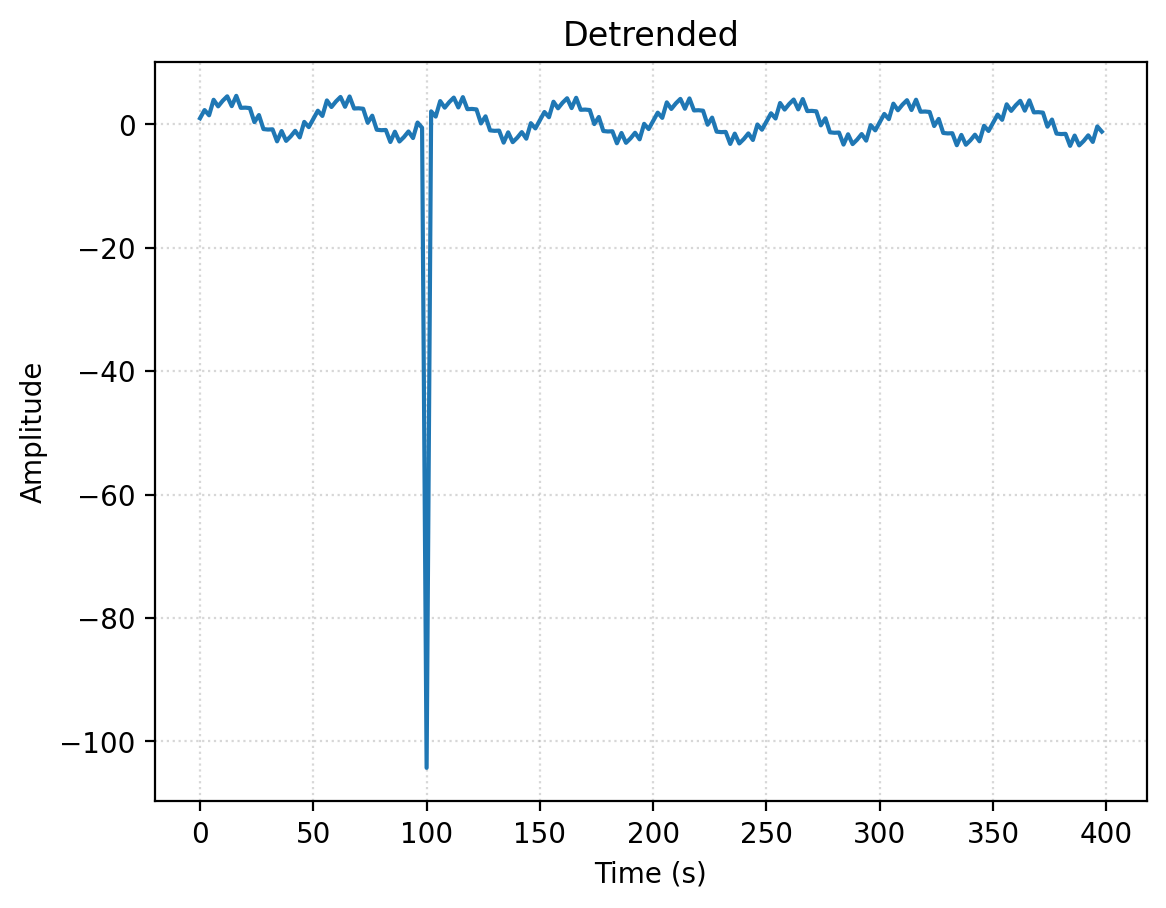

In [7]:
detrended = nilearn.signal.clean(
    signal,
    detrend=True,
    standardize=False,
    ensure_finite=True
)
describe("detrend", detrended)

plt.title("Detrended")
plt.plot(t, detrended)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

## Knob 3 — `standardize`: rescales, doesn't reshape

`standardize` is an **affine** transform: `z = (x − mean) / std`. Subtracting and dividing by constants changes the **y-axis scale**, not the **shape** — so plotted on its own it looks like nothing happened. The proof is in `describe`: `mean` goes `~100 → 0` and `std → ~1`. To _see_ it, overlay raw vs standardized on twin y-axes: identical curves, different scales.

The spike at t≈100 is the `NaN→0` value, now ~11 std below the baseline — a reminder that `0`-fill is only "neutral" once the data is mean-centered.


standardize                  mean=  0.000  std= 0.997  finite=True


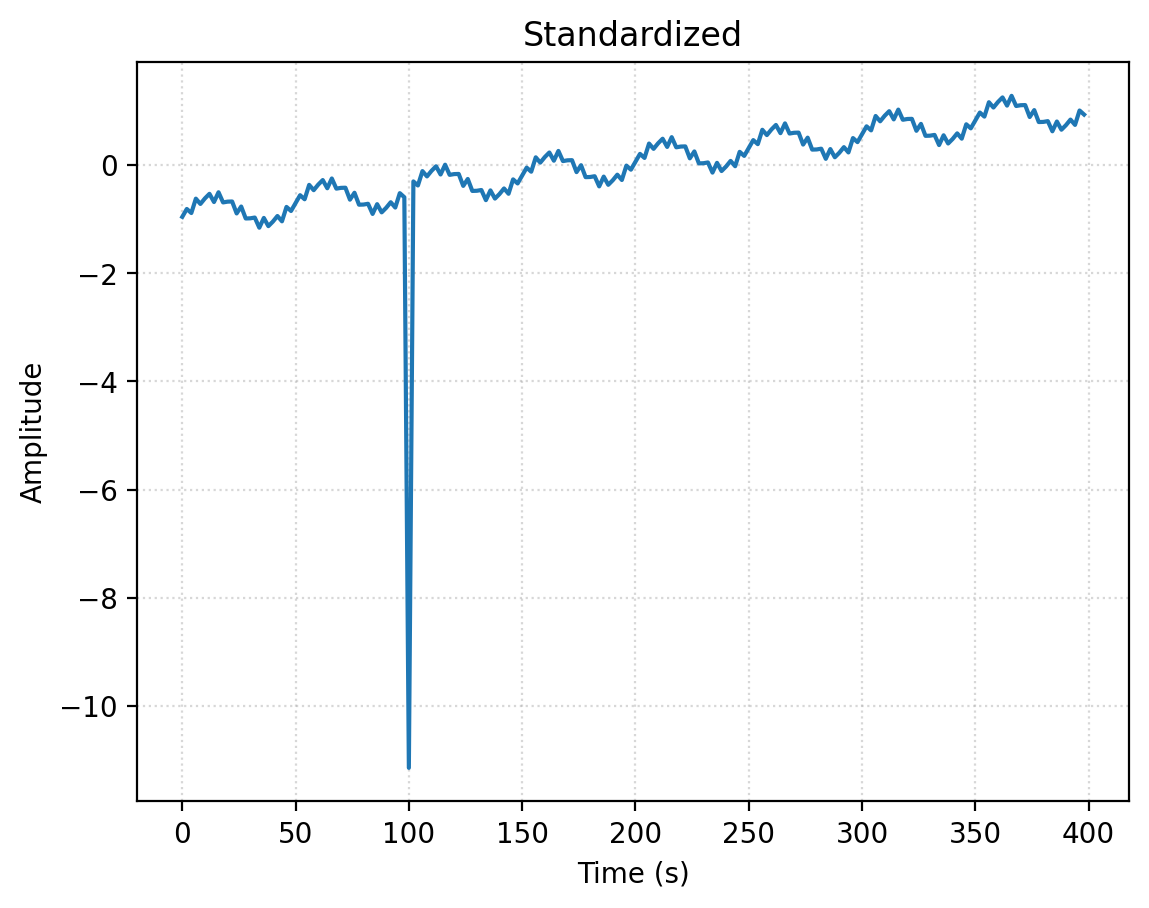

In [8]:
# standardize=True/False is deprecated in recent nilearn; "zscore_sample" is the modern spelling.
standardized = nilearn.signal.clean(
    signal,
    detrend=False,
    ensure_finite=True,
    standardize="zscore_sample"
)
describe("standardize", standardized)

plt.title("Standardized")
plt.plot(t, standardized)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

## Knob 4 — `high_pass` / `low_pass`: temporal filters

Mirror images. **High-pass** keeps fast content and strips the slow drift/baseline, so the signal recenters on 0. **Low-pass** keeps the slow wave and smooths away the fast noise, leaving the baseline intact.

Watch the `NaN→0` sample behave like an **impulse**: high-pass exposes it as a spike to ≈ −100 (the ~100 baseline got subtracted), while low-pass smears it into a dip with **ringing** on either side. Same theme as detrend, now in the frequency domain — one bad sample bleeds into its neighbours.


high_pass 0.01 Hz            mean=  0.026  std= 7.590  finite=True
low_pass 0.10 Hz             mean=109.422  std= 7.798  finite=True


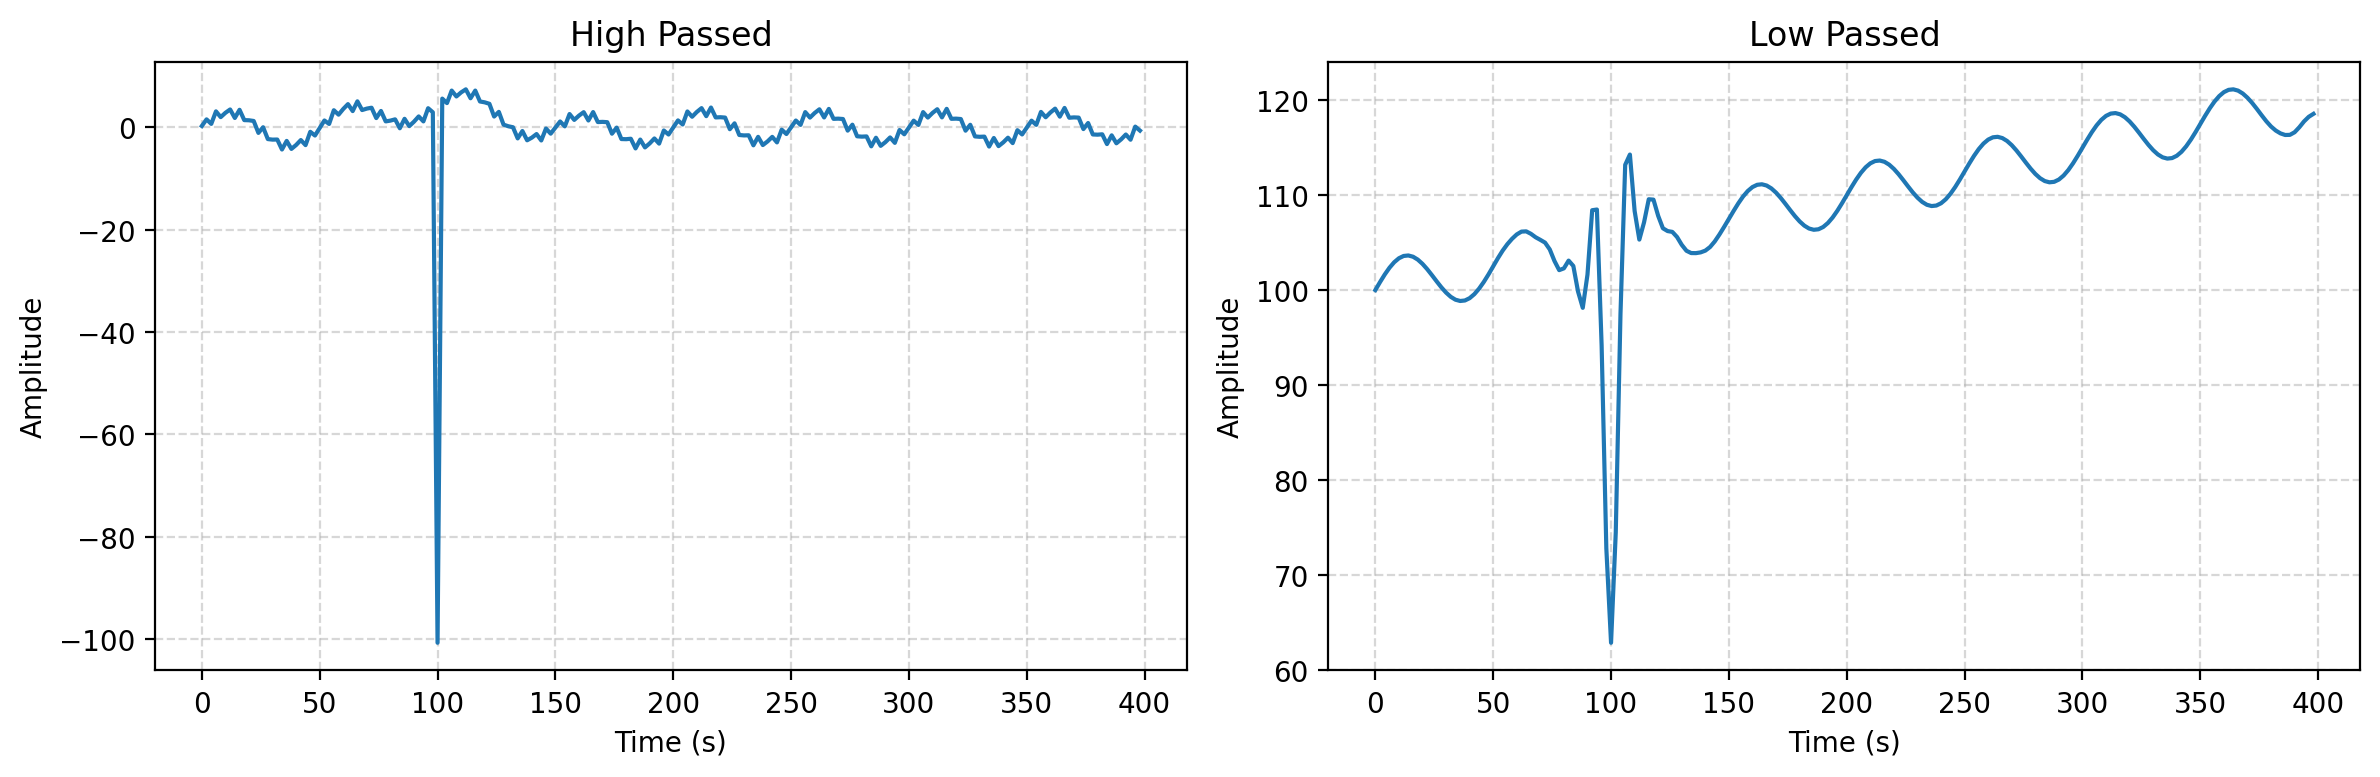

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

high_passed = nilearn.signal.clean(
    signal,
    t_r=t_r,                # sampling interval — required for filtering
    detrend=False,
    standardize=False,
    ensure_finite=True,
    high_pass=0.01
)
describe("high_pass 0.01 Hz", high_passed)

ax1.plot(t, high_passed)
ax1.set_title("High Passed")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")
ax1.grid(True, linestyle="--", alpha=0.5)


low_passed  = nilearn.signal.clean(
    signal,
    t_r=t_r,
    detrend=False,
    standardize=False,
    ensure_finite=True,
    low_pass=0.10
)
describe("low_pass 0.10 Hz",  low_passed)

ax2.plot(t, low_passed)
ax2.set_title("Low Passed")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()